**EDA Fase 1: Diagnóstico de RECH0 (Características del Hogar / Geografía)**

Objetivo: Descubrir empíricamente qué variables y etiquetas contiene realmente este módulo en la ventana histórica 2007-2024. 

No haremos suposiciones de filtrado ni unificación hasta que agrupemos lógicamente las variables e imprimamos su distribución.

In [2]:
import pandas as pd
import gc
from mnp.ingestion.loader import load_endes

# 1. Carga de historial desde 2007 para RECH0
history = load_endes(year=range(2007, 2025), module='household', record='household_characteristics', meta=True)

frames = []
diccionario = {}

# Extraemos y liberamos memoria progresivamente usando pop()
for yr in sorted(list(history.keys())):
    df_yr, meta_yr = history.pop(yr)
    frames.append(df_yr.assign(year=yr))
    diccionario.update(meta_yr.column_names_to_labels)

df_rech0 = pd.concat(frames, ignore_index=True)
del frames
gc.collect() # Forzar limpieza de memoria

print(f"Registros RECH0 totales: {len(df_rech0)}")
print(f"Columnas RECH0 totales: {df_rech0.shape[1]}")

2026-05-31 00:45:20.990 | INFO     | mnp.config:<module>:11 - PROJ_ROOT path is: /Users/abelguevarah/Desktop/invs/malnutrition-research


2026-05-31 00:45:21.096 | INFO     | mnp.ingestion.loader:load_endes:382 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-05-31 00:45:21.361 | INFO     | mnp.ingestion.loader:load_endes:382 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-05-31 00:45:21.728 | INFO     | mnp.ingestion.loader:load_endes:382 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-05-31 00:45:22.078 | INFO     | mnp.ingestion.loader:load_endes:382 - ✓ Cargando registro: RECH0.SAV desde Modulo64 [Alias: household_characteristics]
2026-05-31 00:45:22.299 | INFO     | mnp.ingestion.loader:load_endes:382 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-05-31 00:45:22.529 | INFO     | mnp.ingestion.loader:load_endes:382 - ✓ Cargando registro: RECH0.sav desde Modulo64 [Alias: household_characteristics]
2026-05-31 00:45:22.841 | INFO     | mnp.ingestion.loader:load_e

In [3]:
# 2. Descubrimiento: Porcentaje de nulos y etiquetas de la data real
nulos = df_rech0.isna().mean().sort_values(ascending=False) * 100

print("Variables con > 90% de nulos:")
for col, pct in nulos[nulos > 90].items():
    etiqueta = diccionario.get(col, 'Sin etiqueta')
    print(f"{col:15s} | {pct:5.1f}% | {etiqueta}")

print("\nResto de variables:")
for col, pct in nulos[nulos <= 90].items():
    etiqueta = diccionario.get(col, 'Sin etiqueta')
    print(f"{col:15s} | {pct:5.1f}% | {etiqueta}")

Variables con > 90% de nulos:
HV028           | 100.0% | Peso de muestra masculino
HV031           | 100.0% | Editor de campo
lat_ccpp        |  94.0% | Latitud
long_ccpp       |  94.0% | Longitud
hv022           |  94.0% | Estrato
HV005X          |  94.0% | Factor de ponderación niño menor de 5 años 2015
HV005A          |  94.0% | Sample weight Departamental
NCONGLOME1      |  93.9% | Número de Conglomerado (proveniente del marco)
ubigeo          |  93.8% | ubigeo
nconglome       |  93.8% | Número de Conglomerado (proveniente del marco)

Resto de variables:
hv005           |  89.5% | Factor de ponderacion
HV033           |  89.1% | Ultimate area selection prob.
nomccpp         |  88.0% | Nombre de centro poblado
codccpp         |  88.0% | Codigo de centro poblado
LONGITUDX       |  81.6% | None
LATITUDY        |  81.6% | None
NCONGLOME       |  69.2% | Número de Conglomerado (proveniente del marco)
UBIGEO          |  63.0% | Código de Ubicación Gegráfica
NOMCCPP         |  56.9% | Nom

### Clasificación Inicial por Categoría

In [7]:
# 1. Reorganizamos nuestras categorías con todas las variables agrupadas
categorias_actualizadas = {
    'geografia': [
        'LATITUDY', 'latitudy', 'lat_ccpp',
        'LONGITUDX', 'longitudx', 'long_ccpp',
        'UBIGEO', 'ubigeo', 
        'NOMCCPP', 'nomccpp',
        'codccpp', 'CODCCPP', 
        'HV025',
        'HV024',
        'HV026',
        'HV040'
    ],
    'muestreo': [
        'NCONGLOME1', 'nconglome', 'NCONGLOME',
        'HV001',
        'HV004',
        'HV005X',
        'HV005A',
        'hv005',
        'HV005',
        'HV020',
        'HV021',
        'hv022',
        'HV022',
        'HV023',
        'HV027',
        'HV028',
        'HV033',
        'HV042',
        'HV043',
        'HV044',
    ],
    'administrativa': [
        'year',
        'ID1',
        'HHID', 
        'HV000',
        'HV002', 'HV002A', 
        'HV003',
        'HV008',
        'HV019',
        'HV016',
        'HV006',
        'HV018',
        'HV007',
        'HV015',
        'HV017',
        'HV030',
        'HV031',
        'HV032'
    ],
    'demografia': [
        'HV009',
        'HV010',
        'HV011',
        'HV012',
        'HV013',
        'HV014',
        'HV035',
        'HV041'
    ]
}

**Categoría geografía**
Resultados de la celda anterior la celda anterior agrupados
| Variable | Label | Nulos |
|--|--|--|
| HV024 | Región | 0.0% nulos |
| HV025 | Área de residencia | 0.0% nulos |
| HV026 | Lugar de residencia | 0.6% nulos |
| HV040 | Altitud del conglomerado en metros | 0.0% nulos |
| long_ccpp | Longitud | 94.0% nulos |
| LONGITUDX | Longitud | 81.6% nulos |
| longitudx | Longitud del conglomerado | 39.8% nulos |
| lat_ccpp | Latitud | 94.0% nulos |
| LATITUDY | Latitud | 81.6% nulos |
| latitudy | Latitud del conglomerado | 39.8% nulos |
| NOMCCPP | Nombre del Centro Poblado | 56.9% nulos |
| nomccpp | Nombre de centro poblado | 88.0% nulos |
| CODCCPP | Codigo de Centro Poblado | 56.9% nulos |
| codccpp | Codigo de centro poblado | 88.0% nulos |
| UBIGEO | Código de Ubicación Geográfica | 63.0% nulos |
| ubigeo | ubigeo | 93.8% nulos |

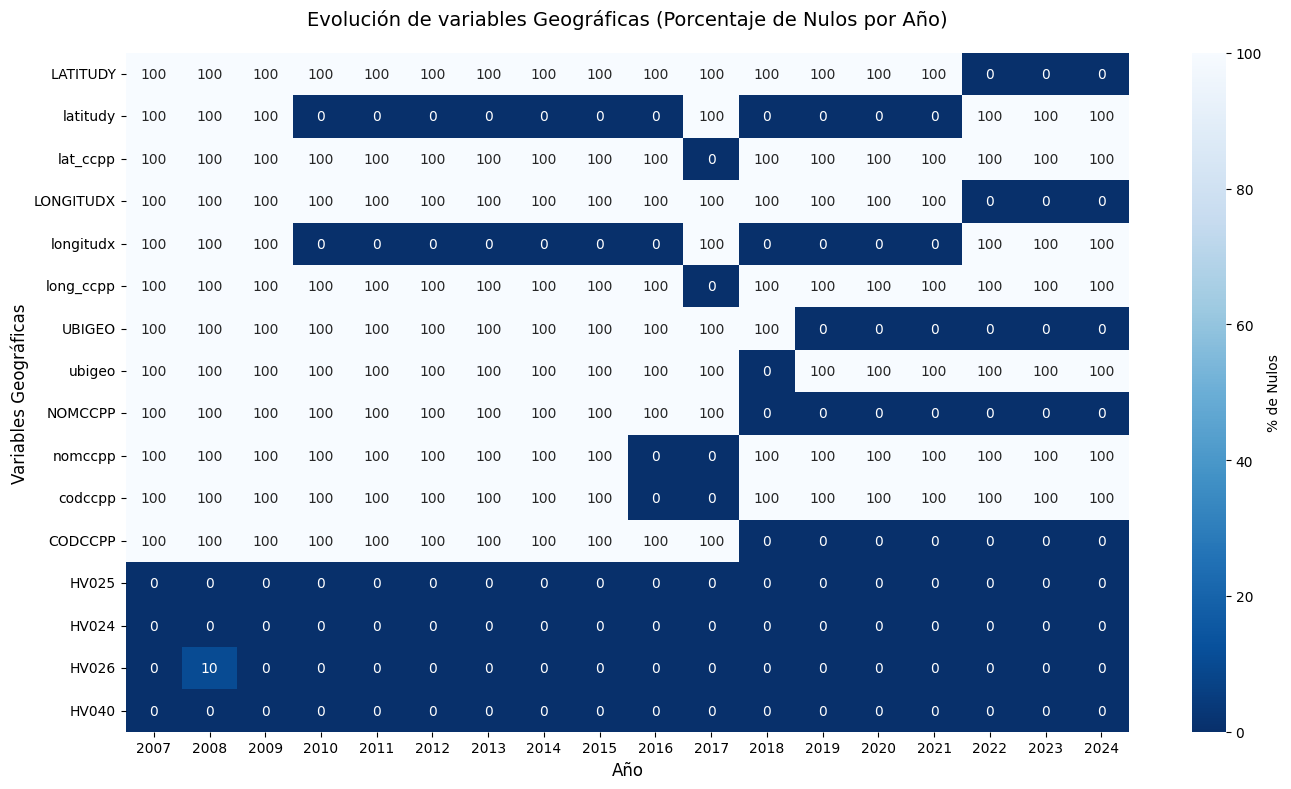

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Análisis de disponibilidad temporal para Geografía
vars_geo = categorias_actualizadas['geografia']
# Nos aseguramos de tomar solo las variables que existen en el dataframe
vars_geo = [v for v in vars_geo if v in df_rech0.columns] 

# Calculamos el % de nulos por año para las variables geográficas
geo_por_ano = df_rech0.groupby('year')[vars_geo].apply(lambda df: df.isna().mean() * 100)

# Visualizamos el cambio a través de los años con un Heatmap
#display(geo_por_ano.T)

plt.figure(figsize=(14, 8))
# Transponemos (.T) para que los años queden en las columnas y las variables en las filas
sns.heatmap(geo_por_ano.T, annot=True, fmt=".0f", cmap="Blues_r", cbar_kws={'label': '% de Nulos'})
plt.title("Evolución de variables Geográficas (Porcentaje de Nulos por Año)", pad=20, fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Variables Geográficas", fontsize=12)
plt.tight_layout()
plt.show()

Conclusiones del Análisis Geográfico (Resolución de Schema Drift)

Coordenadas Geográficas (Latitud y Longitud):
- 2010 a 2016 y 2018 a 2021: Usaron latitudy y longitudx (0% nulos).
- 2017 (El año rebelde): Cambiaron el nombre exclusivamente a lat_ccpp y long_ccpp.
- 2022 a 2024: Empezaron a usar mayúsculas con LATITUDY y LONGITUDX.
- 2007 a 2009: Simplemente no hay coordenadas registradas en esos años (100% de nulos en todas las variantes).

Código de Ubicación Geográfica (UBIGEO):
- 2007 a 2017: No incluyeron el UBIGEO (código de 6 dígitos) en este módulo específico. (Nota: No es crítico, porque seguimos teniendo HV024 que es la Región/Departamento, por lo que no perdemos representatividad macro).
- 2018: Lo introdujeron por primera vez en minúsculas como ubigeo.
- 2019 a 2024: Decidieron pasarlo a mayúsculas como UBIGEO.

Centros Poblados:
- 2007 a 2015: No se capturaba explícitamente el nombre ni el código del centro poblado en la base de datos pública del módulo de vivienda.
- 2016 y 2017: Se introdujo como nomccpp y codccpp (minúsculas).
- 2018 a 2024: Se estandarizó permanentemente a mayúsculas (NOMCCPP y CODCCPP).

Estándar Internacional DHS (Demographic and Health Surveys):
- Variables como HV024 (Región), HV025 (Tipo de área urbana/rural), HV026 (Lugar de residencia) y HV040 (Altitud) son parte del núcleo mundial de la encuesta DHS. Como resultado, están perfectamente estandarizadas y presentan un 0% de nulos en casi toda la historia (con una pequeñísima anomalía del 10% en HV026 para el 2008).


**Categoría de muestreo**
|Variable|Label|Nulos|
|--|--|--|
| HV001 | Conglomerado | 0.0% nulos |
| HV004 | Unidad última de muestreo | 0.0% nulos |
| HV005X | Factor de ponderación niño menor de 5 años 2015 | 94.0% nulos |
| HV005A | Sample weight Departamental | 94.0% nulos |
| HV005 | Factor de ponderación | 11.0% nulos |
| hv005 | Factor de ponderacion | 89.5% nulos |
| HV020 | Muestra de alguna vez en union | 0.0% nulos |
| hv022 | Estrato | 94.0% nulos |
| HV022 | Estrato | 6.0% nulos |
| HV021 | Unidad de muestreo primario - conglomerado | 0.0% nulos |
| HV023 | Dominio | 0.0% nulos |
| HV027 | Selección para hombre/esposo | 0.0% nulos |
| HV028 | Peso de muestra masculino | 100.0% nulos |
| HV033 | Ultimate area selection prob. | 89.1% nulos |
| HV042 | Selección para medición de hemoglobina | 0.0% nulos |
| HV043 | Hogares seleccionados para el módulo de mujeres de estado | 0.0% nulos |
| HV044 | Selección para el módulo de violencia familiar | 0.0% nulos |
| nconglome | Número de Conglomerado proveniente del marco | 93.8% nulos |
| NCONGLOME1 | Número de Conglomerado proveniente del marco | 93.9% nulos |
| NCONGLOME | Número de Conglomerado proveniente del marco | 69.2% nulos |

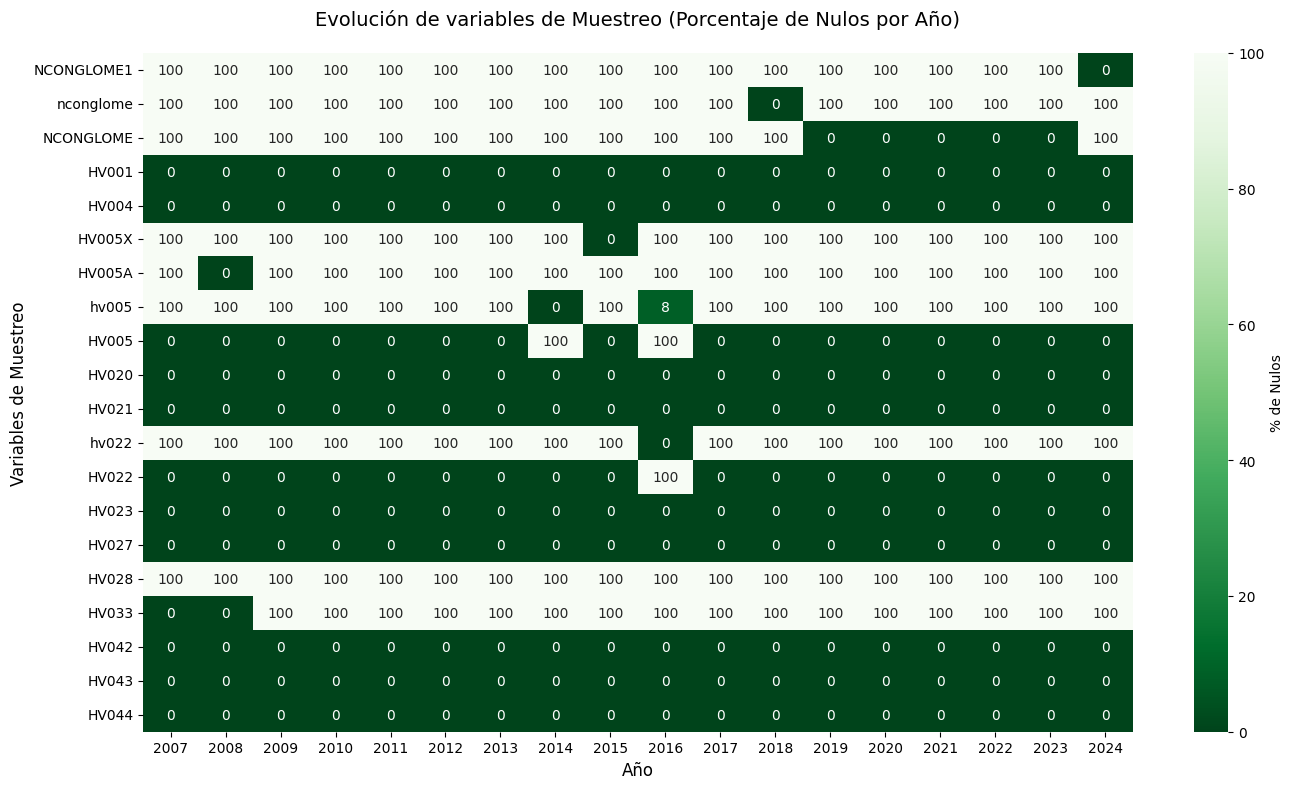

In [ ]:
# 3. Análisis de disponibilidad temporal para Muestreo
vars_muestreo = categorias_actualizadas['muestreo']
# Nos aseguramos de tomar solo las variables que existen en el dataframe
vars_muestreo = [v for v in vars_muestreo if v in df_rech0.columns] 

# Calculamos el % de nulos por año para las variables de muestreo
muestreo_por_ano = df_rech0.groupby('year')[vars_muestreo].apply(lambda df: df.isna().mean() * 100)

# Visualizamos el cambio a través de los años con un Heatmap
#display(muestreo_por_ano.T)

plt.figure(figsize=(14, 8))
# Transponemos (.T) para que los años queden en las columnas y las variables en las filas
sns.heatmap(muestreo_por_ano.T, annot=True, fmt=".0f", cmap="Greens_r", cbar_kws={'label': '% de Nulos'})
plt.title("Evolución de variables de Muestreo (Porcentaje de Nulos por Año)", pad=20, fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Variables de Muestreo", fontsize=12)
plt.tight_layout()
plt.show()


### Conclusiones del Análisis de Muestreo (Resolución de Schema Drift)

**1. Conglomerado Oficial y Unidad de Muestreo (Estándar Internacional DHS):**
- Variables como `HV001` (Conglomerado) y `HV004` (Unidad Última de Muestreo) pertenecen al núcleo del estándar mundial DHS. Son **estables y perfectas**, presentando un **0% de nulos** en toda la ventana histórica (2007-2024). Serán nuestras referencias principales.

**2. Número de Conglomerado del Marco Muestral Peruano (Variable Local INEI):**
El INEI manejó su propia variable de marco muestral, sufriendo de "Schema Drift":
- **2007 a 2017:** No existía en la base pública. *(No afecta, usamos la internacional `HV001`)*.
- **2018:** Se introdujo bajo el nombre `nconglome` (minúsculas).
- **2019 a 2023:** Se estandarizó a mayúsculas como `NCONGLOME`.
- **2024:** Se renombró añadiéndole un número al final, quedando como `NCONGLOME1`.

**3. Factores de Ponderación (Pesos Muestrales):**
- **La variable maestra (`HV005` y `hv005`):** Es el factor de expansión oficial usado casi todos los años (0% nulos). En **2014 y 2016**, el INEI registró este peso en minúsculas (`hv005`). *(Curiosamente, en 2016 este peso arrojó un 8.47% de nulos).*
- **Pesos Especiales Temporales:**
  - `HV005A` (2008): Factor alternativo a nivel "Departamental".
  - `HV005X` (2015): Factor calibrado exclusivamente para "Niños menores de 5 años".

**4. Unidades de Diseño (Estrato, Dominio y Selección):**
- **El núcleo perfecto:** Las variables `HV020`, `HV021` (Unidad de Muestreo Primario / PSU), `HV023` (Dominio de Estrato) y `HV027` (Selección de hombres) se mantienen **impecables con 0% de nulos** de principio a fin.
- **El caso del Estrato (`HV022` y `hv022`):** Es la variable oficial usada todos los años. Sin embargo, exclusivamente en **2016** se registró en minúsculas como `hv022`.

**5. Módulos de Selección Específica y Variables Descartables:**
- Las variables que indican si el hogar fue seleccionado para un submódulo específico (`HV042` para Hemoglobina, `HV043` para Estado de la mujer, y `HV044` para Violencia Familiar) son estándar y presentan un **0% de nulos**.
- **Variables Descartables (Eliminación Segura):**
  - `HV028` (Peso de muestra masculino): Tiene **100% de nulos** en toda la historia (la ENDES en Perú se enfoca en MEF y niños).
  - `HV033` (Probabilidad de selección de área): Fue requerida solo en **2007 y 2008**, y desapareció por completo después.

**Categoría administrativa**
| Variables | Etiqueta | Nulos |
|--|--|--|
| ID1 | Año | 27.6% nulos |
| year | Año | 0.0% nulos |
| HHID | Identificacion Cuestionario del Hogar | 0.0% nulos |
| HV000 | Código del país | 0.0% nulos |
| HV002 | Vivienda | 0.0% nulos |
| HV002A | Hogar | 24.5% nulos |
| HV003 | Número de orden del Informante del cuestionario | 0.0% nulos |
| HV006 | Month of interview | 43.1% nulos |
| HV007 | Año de entrevista | 6.2% nulos |
| HV008 | Fecha de entrevista meses - CMC | 0.0% nulos |
| HV015 | Resultado de la entrevista en el hogar | 0.0% nulos |
| HV016 | Day of interview | 43.1% nulos |
| HV017 | Número de visitas | 0.0% nulos |
| HV018 | Interviewer identification | 43.1% nulos |
| HV019 | Keyer identification | 46.6% nulos |
| HV030 | Supervisor de campo | 0.0% nulos |
| HV031 | Editor de campo | 100.0% nulos |
| HV032 | Editor de la oficina | 0.0% nulos |

Distribución explícita (Matriz) para variables Administrativas:


year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
year,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ID1,100.0,100.0,100.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0
HHID,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV002,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV002A,100.0,100.0,100.000000,100.0,100.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV003,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV008,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV019,0.0,0.0,0.000000,0.0,0.0,0.0,69.947747,4.011726,0.000000,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
HV016,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.003294,0.002725,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0


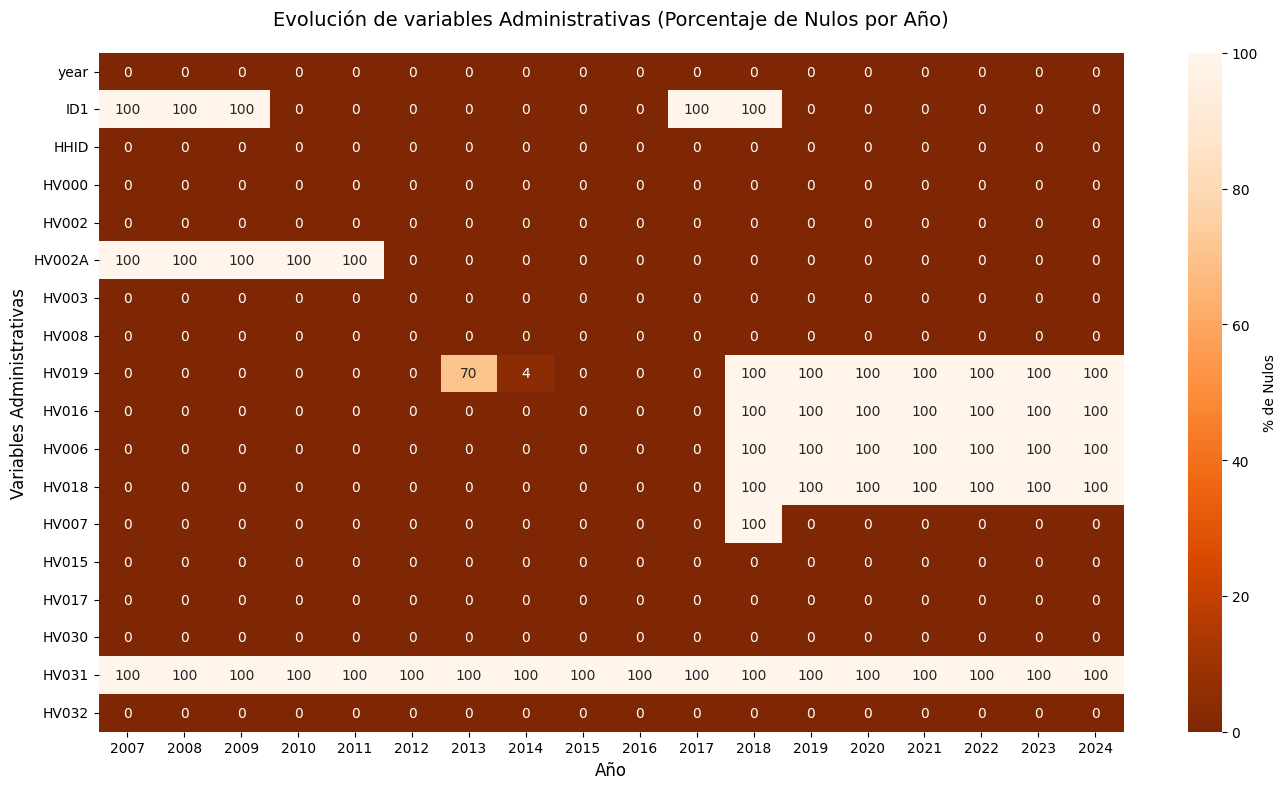

In [17]:
# 4. Análisis de disponibilidad temporal para Administrativa

vars_admin = categorias_actualizadas['administrativa']
vars_admin = [v for v in vars_admin if v in df_rech0.columns] 
# Calculamos el % de nulos por año para las variables administrativas
admin_por_ano = df_rech0.groupby('year')[vars_admin].apply(lambda df: df.isna().mean() * 100)
print("Distribución explícita (Matriz) para variables Administrativas:")
display(admin_por_ano.T)
# Visualizamos con un Heatmap naranja
plt.figure(figsize=(14, 8))
sns.heatmap(admin_por_ano.T, annot=True, fmt=".0f", cmap="Oranges_r", cbar_kws={'label': '% de Nulos'})
plt.title("Evolución de variables Administrativas (Porcentaje de Nulos por Año)", pad=20, fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Variables Administrativas", fontsize=12)
plt.tight_layout()
plt.show()


### Conclusiones del Análisis de Variables Administrativas

**1. Identificadores Básicos (La Llave Maestra):**
- Las variables `HHID` (Identificador alfanumérico único del hogar), `HV000` (Código del país) y `HV002` (Número de Vivienda) son el núcleo de la DHS y presentan un **0% de nulos** histórico (2007-2024). 
- `HV002A` (Número de Hogar dentro de la vivienda) fue introducida recién en el 2012. No nos afecta, ya que el `HHID` es la *Primary Key* suficiente para identificar cada hogar en los cruces de la Fase 3.

**2. Cronología y Fechas de Entrevista:**
- **La variable matemática:** `HV008` (Fecha CMC - Century Month Code) y nuestro `year` inyectado tienen 0% nulos, dándonos la cronología perfecta de la entrevista.
- **Mes (`HV006`) y Día (`HV016`):** Estas sufrieron un "apagón de privacidad" a partir de 2018 (100% nulos). Conservaremos el mes (`HV006`) por registro histórico para los años donde sí existe (2007-2017).
- **Año original (`HV007`):** Por algún motivo de esquema, el año original de la encuesta fue omitido de esta columna exclusivamente en el 2018 (100% nulos), pero está presente (0% nulos) en todos los demás años. La conservaremos.

**3. Variables de Control de Campo y Personal:**
- **El Informante (`HV003`):** El "Número de orden del Informante" está **perfectamente documentado con 0% de nulos** histórico. Siempre sabremos qué miembro del hogar fue el que contestó el cuestionario.
- `HV015` (Resultado final), `HV017` (Número de visitas), `HV030` (Supervisor) y `HV032` (Editor de oficina) están casi perfectas (~0% nulos).
- **Anonimización del Personal:** Los identificadores del equipo de campo (`HV018` Entrevistador y `HV019` Digitador) fueron censurados permanentemente por el INEI desde el 2018.
- `HV031` (Editor de campo) es insalvable, jamás fue recopilada (100% nulos histórico).

***

### Limpieza de la Categoría Administrativa (Ajustada)

Y aquí tienes el código actualizado, donde he sacado a `HV006` y `HV007` de la lista de eliminación para que las conservemos intactas en tu DataFrame.

```python
# 12. Eliminación de Variables Administrativas Inútiles o Anonimizadas
# Conservamos HV003, HV006 y HV007 completas en el dataset.
columnas_a_borrar_admin = [
    'ID1',      # Año redundante (ya tenemos nuestro 'year' y 'HV007')
    'HV016',    # Día anonimizado permanentemente desde 2018 
    'HV018',    # ID Entrevistador anonimizado desde 2018
    'HV019',    # ID Digitador anonimizado desde 2018
    'HV031'     # Editor de campo (100% nulos)
]

# Solo eliminamos las que realmente existan en el dataframe
columnas_a_borrar_admin = [col for col in columnas_a_borrar_admin if col in df_rech0.columns]
df_rech0.drop(columns=columnas_a_borrar_admin, inplace=True)

print(f"Se eliminaron {len(columnas_a_borrar_admin)} variables administrativas insalvables.")
```

**Categoría de demografia**
| Variables | Etiqueta | Nulos |
|--|--|--|
| HV009 | Total de personas en el hogar | 0.0% nulos | 
| HV010 | Número de mujeres elegibles para entrevista individual | 0.0% nulos | 
| HV011 | Número de hombres elegibles por hogar | 0.0% nulos | 
| HV012 | Número de miembros de jure - residentes habituales | 0.0% nulos | 
| HV013 | Número de miembros de facto - pernoctaron | 0.0% nulos | 
| HV014 | Número de niños menores de 5 años | 0.0% nulos | 
| HV035 | Número de niños elegibles para altura y peso | 0.0% nulos | 
| HV041 | Número de mujeres con medición de peso y talla | 0.0% nulos | 


Distribución explícita (Matriz) para variables de Demografía:


year,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
HV009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV010,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV013,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HV041,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


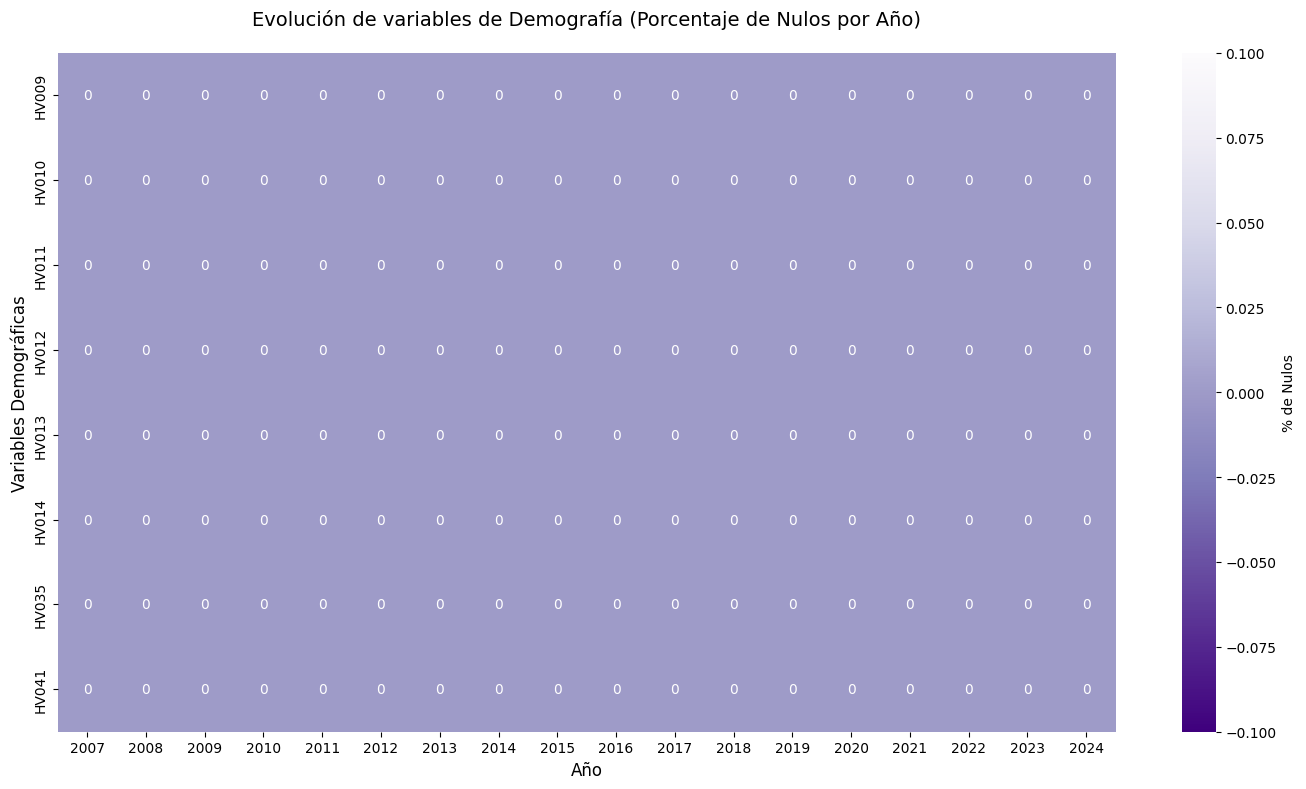

In [ ]:
# 5. Análisis de disponibilidad temporal para Demografía

vars_demo = categorias_actualizadas['demografia']
vars_demo = [v for v in vars_demo if v in df_rech0.columns] 
# Calculamos el % de nulos por año para las variables demográficas
demo_por_ano = df_rech0.groupby('year')[vars_demo].apply(lambda df: df.isna().mean() * 100)
print("Distribución explícita (Matriz) para variables de Demografía:")
display(demo_por_ano.T)
# Visualizamos con un Heatmap morado
plt.figure(figsize=(14, 8))
sns.heatmap(demo_por_ano.T, annot=True, fmt=".0f", cmap="Purples_r", cbar_kws={'label': '% de Nulos'})
plt.title("Evolución de variables de Demografía (Porcentaje de Nulos por Año)", pad=20, fontsize=14)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Variables Demográficas", fontsize=12)
plt.tight_layout()
plt.show()

### Conclusiones del Análisis de Variables Demográficas

**El Núcleo Sagrado de la ENDES (0% Nulos Histórico):**
La categoría demográfica es absolutamente perfecta. Todas las variables clave para el conteo y filtro de nuestra población objetivo se mantienen intactas y completas desde el 2007 hasta el 2024, sin sufrir ningún tipo de alteración de nombres ni censura:
- `HV009`: Total de personas en el hogar.
- `HV012` y `HV013`: Miembros residentes habituales (de jure) y miembros que pernoctaron (de facto).
- **Población Objetivo:** `HV010` (Mujeres elegibles) y `HV014` (Niños menores de 5 años).
- **Filtros Antropométricos:** `HV035` (Niños elegibles para medición) y `HV041` (Mujeres medidas).

*Conclusión Técnica:* No se requiere absolutamente ninguna limpieza, consolidación ni eliminación en este bloque. Las variables están listas para ser usadas en cualquier modelo predictivo o filtro poblacional.